# Single Color Correction Validation
Goal: recreating plots in Figure 7 of DMTN 266 with DP1 data
https://dmtn-266.lsst.io/DMTN-266.pdf

Author: Maya Redden, msredden@stanford.edu

In [54]:
#import general packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler


from astropy.table import vstack
from astropy.table import Table, join
import astropy.units as u
from scipy.optimize import curve_fit

from astropy.modeling.models import BlackBody
from astropy.constants import c
from utils import BB
from utils import apply_DCR, weighted_avg_and_std

from scipy import integrate

#import LSST packages
from lsst.rsp import get_tap_service
import lsst.daf.butler as dafButler
from lsst.geom import LinearTransform, radians
from lsst.afw.geom import Quadrupole, Ellipse

from utils import apply_filter, rebin

field_centers = {
    "47 Tuc": [6.02, -72.08],
    "SV 38 7": [37.86, 6.98],
    "Fornax": [40.00, -34.45],
    "ECDFS": [53.13, -28.10],
    "EDFS": [59.10, -48.73],
    "SV 95 -25": [95.00, -25.00],
    "Seagull": [106.23, -10.51],
}

In [103]:
# Run a wide object search around the ECDFS

# query_simple looks for stars (refExtendedness = 0.0) in the ECDFS

query_simple = """ SELECT TOP 400 coord_dec,
            coord_ra,
            g_cModelMag,
            r_cModelMag,
            i_cModelMag,
            u_cModelMag,
            z_cModelMag,
            shape_xx,
            shape_xy,
            shape_yy,
            refExtendedness,
            g_calib_psf_reserved,
            g_calib_psf_used,
            g_calib_astrometry_used,
            g_cModelMag - r_cModelMag as grColor,
            g_cModelMag - i_cModelMag as giColor,
            r_cModelMag - z_cModelMag as rzColor,
            u_cModelMag - g_cModelMag as ugColor
    FROM dp1.Object 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', 53.13, -28.10, 3600/3600))=1
            AND (g_cModelMag < 23 AND g_cModelMag > 18)
            AND refExtendedness = 0
            """

# Other constraints to consider:
# AND g_calib_psf_used = 0
# AND (g_cModelMag < 23 AND g_cModelMag > 18)
# AND refExtendedness = 0.0
# AND (r_cModelMag - g_cModelMag) > 0


service = get_tap_service("tap")
job = service.submit_job(query_simple)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
object_table = job.fetch_result().to_table()

print(len(object_table))

Job phase is COMPLETED
400


Mean g-i color for astrometry reference objects: 1.588818588256836


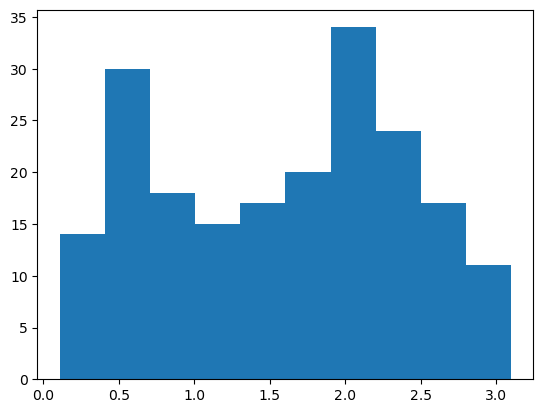

In [104]:
plt.hist(object_table['giColor'][object_table['g_calib_astrometry_used'] == 1])
print('Mean g-i color for astrometry reference objects:', np.mean(object_table['giColor'][object_table['g_calib_astrometry_used'] == 1]))

In [105]:
# Avoid doing this more than once (takes a really long time) 
def source_query(coords):
    search_radius = 2 #arcsec
    search_circles = [f"CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1" for ra, dec in np.array([coords['coord_ra'], coords['coord_dec']]).T]
    search_string = " OR ".join(map(str, search_circles))
    
    source_query = f"""SELECT band,
                coord_dec,
                coord_ra,
                dec,
                decErr,
                detector,
                ra,
                raErr,
                ra_dec_Cov,
                visit,
                psfFlux,
                psfFluxErr
                
        FROM dp1.Source 
        WHERE (band = 'g' OR band = 'i' or band = 'u' or band = 'r' or band = 'z') AND ({search_string})
        AND psfFluxErr / psfFlux < 0.05
        """
    
    
    job = service.submit_job(source_query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    print('Job phase is', job.phase)
    if job.phase == 'ERROR':
        job.raise_if_error()
    assert job.phase == 'COMPLETED'
    source_table = job.fetch_result().to_table()
    return source_table


source_table = source_query(object_table['coord_ra', 'coord_dec'])

source_table.write("scrap/singleColor_source_table_400obj.ecsv")

print(len(source_table))
print('u band sources returned', np.sum(source_table['band'] == 'u'))
print('g band sources returned', np.sum(source_table['band'] == 'g'))
print('r band sources returned', np.sum(source_table['band'] == 'r'))
print('i band sources returned', np.sum(source_table['band'] == 'i'))
print('z band sources returned', np.sum(source_table['band'] == 'z'))


Job phase is COMPLETED
23059
u band sources returned 214
g band sources returned 6499
r band sources returned 5561
i band sources returned 5517
z band sources returned 5268


In [106]:
#visit table
visit_IDs = source_table['visit']

unique_visits = np.unique(visit_IDs)

visit_string = "','".join(map(str, unique_visits))

visit_query = f"""SELECT airmass,
                        altitude,
                        azimuth,
                        band as band_visit,
                        dec as dec_visit,
                        expTime,
                        ra as ra_visit,
                        skyRotation,
                        visit,
                        zenithDistance,
                        expMidptMJD 
    FROM dp1.Visit 
    WHERE visit IN ('{visit_string}')"""


job = service.submit_job(visit_query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
visit_table = job.fetch_result().to_table()

print(len(visit_table))

Job phase is COMPLETED
671


In [107]:
#join source and visit tables into a master table
master = join(source_table, visit_table, keys = 'visit')

In [108]:
# Add color columns from object_table to master by coordinate matching.
# Uses search_around_sky for a fully vectorized cross-match (no iteration over master).
# Master rows within 2" of more than one object_table entry get NaN colors.

from astropy.coordinates import SkyCoord, search_around_sky

master_coords = SkyCoord(ra=np.array(master['ra']) * u.deg, dec=np.array(master['dec']) * u.deg)
object_coords = SkyCoord(ra=np.array(object_table['coord_ra']) * u.deg, dec=np.array(object_table['coord_dec']) * u.deg)

# All (master, object) pairs within 2 arcsec
idx_master, idx_obj, sep2d, _ = search_around_sky(master_coords, object_coords, 2 * u.arcsec)

# Find which master indices appear more than once (ambiguous matches)
unique_master_ids, counts = np.unique(idx_master, return_counts=True)
single_match_ids = unique_master_ids[counts == 1]

# Keep only pairs where the master row has exactly one match
keep = np.isin(idx_master, single_match_ids)
idx_master_unique = idx_master[keep]
idx_obj_unique = idx_obj[keep]

# Add color columns to master, NaN by default
color_cols = ['grColor', 'giColor', 'rzColor', 'ugColor', 'coord_ra', 'coord_dec']
for col in color_cols:
    col_data = np.full(len(master), np.nan)
    col_data[idx_master_unique] = np.array(object_table[col])[idx_obj_unique]
    master[col +"_obj"] = col_data

print(f"Total master rows:        {len(master)}")
print(f"Uniquely matched:         {len(idx_master_unique)}")
print(f"Ambiguous (NaN colors):   {int(np.sum(counts > 1))}")
print(f"Unmatched (no object):    {len(master) - len(unique_master_ids)}")

Total master rows:        23059
Uniquely matched:         23059
Ambiguous (NaN colors):   0
Unmatched (no object):    0


In [109]:

from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord
def add_parallactic_angle(table, ra_col = 'ra', dec_col = 'dec', expMidptMJD_col = 'expMidptMJD', lat = -30.244633,lon = -70.749417, height = 2647):
    # Calculate the parallactic angle and add to the table
    
    loc = EarthLocation(lat = lat * u.deg, lon = lon * u.deg, height = height * u.m)
    
    times = Time(table[expMidptMJD_col], format = 'mjd', scale = 'utc')
    lst = times.sidereal_time(kind = 'mean', longitude = loc.lon)
    HA = (lst - Angle(list(table[ra_col])* u.deg)).wrap_at(180*u.deg)
    
    H_rad = HA.to(u.rad).value
    phi = Angle(lat * u.deg).to(u.rad).value #lat * np.pi/180
    delta = Angle(np.array(table[dec_col])*u.deg).to(u.rad).value #np.array(master['dec_1']) * np.pi/180
    
    numerator = np.sin(H_rad)
    denominator = np.tan(phi) * np.cos(delta) - np.sin(delta) * np.cos(H_rad)
    
    q_rad = np.arctan2(numerator, denominator)   # result in radians
    q = q_rad * u.rad
    
    # normalize to (-180,180] or whatever you prefer — here we return angle wrapped to [-180,180)
    q = Angle(q).wrap_at(360*u.deg)

    table['q'] = q.value

    return table
    
master = add_parallactic_angle(master)

print(master['q'][0:10])

        q         
------------------
1.7825570364880172
1.7837132624205796
1.7840085146821332
1.7831253629202903
1.7828418661888827
1.7842576651098276
1.7837256276115738
1.7825495676994865
1.7895501115596555
1.7817955270041639


In [110]:
def compute_dR_and_err(center_ra, center_dec, ra, dec, par, raErr, decErr, ra_dec_Cov):
        # For a trial center, compute projected zenith offset dR and propagated uncertainty dR_err.
        dR = np.zeros(len(ra))
        dR_err = np.zeros(len(ra))

        for i in range(len(ra)):
            # Rotation from RA/Dec offsets into azimuth/altitude frame using parallactic angle q.
            cq, sq = np.cos(par[i]), np.sin(par[i])
            rot = np.array([[cq, -sq], [sq, cq]])

            dRA = (ra[i] - center_ra[i]) * np.cos(dec[i] * np.pi / 180)
            dDec = dec[i] - center_dec[i]
            _, dalt = rot @ np.array([[dRA, dDec]]).T
            dR[i] = dalt

            # Propagate RA/Dec covariance into rotated frame and keep altitude component uncertainty.
            cov_matrix = np.array([[raErr[i]**2, ra_dec_Cov[i]],
                                   [ra_dec_Cov[i], decErr[i]**2]])
            r_err_matrix = rot @ cov_matrix @ rot.T
            dR_err[i] = np.sqrt(np.abs(r_err_matrix[1, 1]))

        # Keep only finite, positive uncertainties for weighted residuals.
        finite_mask = np.isfinite(dR) & np.isfinite(dR_err) & (dR_err > 0)
        return dR, dR_err, finite_mask


par = np.array(master['q'])
center_ra = np.array(master['coord_ra_obj'])
center_dec = np.array(master['coord_dec_obj'])
ra = np.array(master['ra'])
dec = np.array(master['dec'])
raErr = np.array(master['raErr'])
decErr = np.array(master['decErr'])
ra_dec_Cov = np.array(master['ra_dec_Cov'])

dR, dR_err, finite_mask = compute_dR_and_err(center_ra, center_dec, ra, dec, par, raErr, decErr, ra_dec_Cov)
master['dR'] = dR
master['dR_err'] = dR_err

/tmp/ipykernel_3258/2333573139.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


In [111]:
master['ra','coord_ra_obj', 'giColor_obj', 'q', 'airmass'][0:10]

ra,coord_ra_obj,giColor_obj,q,airmass
deg,,,,
float64,float64,float64,float64,float64
52.763573385619985,52.76357542498395,2.5771255493164062,1.7825570364880172,1.03979582779195
52.78020729604644,52.78020461877936,0.30030250549316406,1.7837132624205796,1.03979582779195
52.794885468599816,52.79488527559312,2.6313724517822266,1.7840085146821332,1.03979582779195
52.76860013986683,52.768600415048276,2.1909427642822266,1.7831253629202903,1.03979582779195
52.79594052573693,52.79593973563938,1.3325252532958984,1.7828418661888827,1.03979582779195
52.750651749189835,52.75065450097767,2.789243698120117,1.7842576651098276,1.03979582779195
52.7868126406138,52.78681249435695,2.032743453979492,1.7837256276115738,1.03979582779195
52.752656473556655,52.752658054053185,2.189573287963867,1.7825495676994865,1.03979582779195


[-44.18217329]


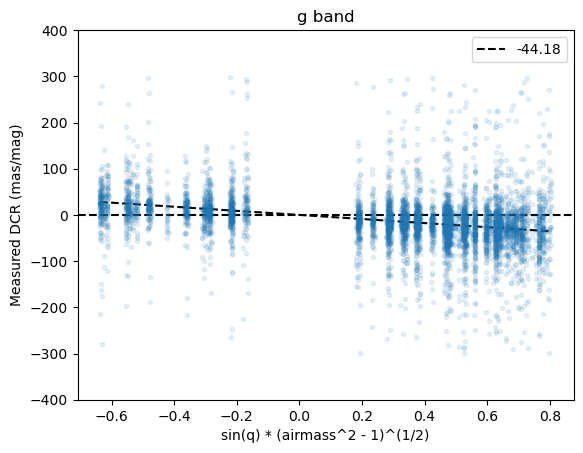

[-11.03987737]


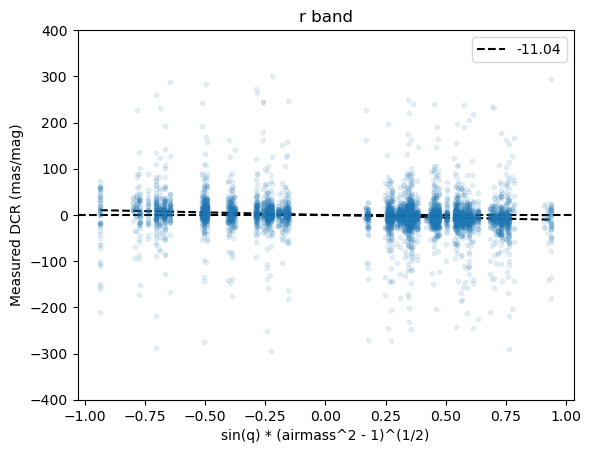

[-3.16343906]


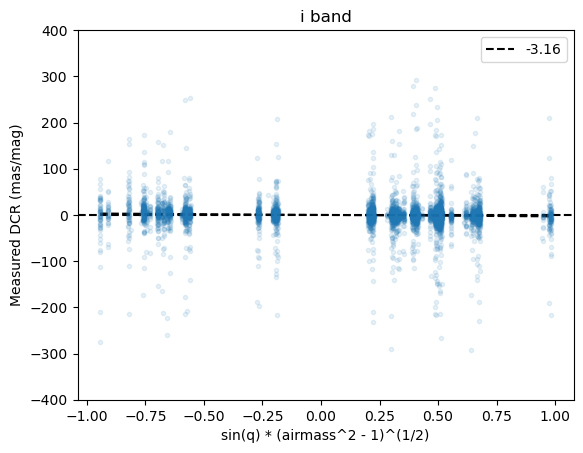

In [113]:


# linear fit
def lin(x, a):
    return a * x


for band in 'gri':
    band_mask = master['band'] == band
    
    airmass = master[band_mask]['airmass']
    delta_RA = (master[band_mask]['ra'] - master[band_mask]['coord_ra_obj']) * 3600 * 1000
    RA_err = master[band_mask]['raErr'] * 3600 * 1000
    dR = master[band_mask]['dR'] * 3600 * 1000
    dRerr = master[band_mask]['dR_err'] * 3600 * 1000
    dColor = master[band_mask]['giColor_obj'] - 1.59 #subtracts the average g-i color of stars used for astrometric calibration
    q = master[band_mask]['q']
    
    z = np.arccos(1 / airmass) * 180 / np.pi
    
    y = delta_RA/dColor
    yerr = RA_err/dColor
    # x = (airmass**2 - 1)**(1/2)
    x =  np.tan(z  * np.pi/180) *np.sin(q) 

    mask = (np.abs(y) < 300)
    y = y[mask]
    x = x[mask]
    yerr = yerr[mask]

    popt, pcov = curve_fit(lin, x, y, p0 = [0])
    print(popt)


    plt.errorbar(x, y, fmt = '.', alpha = 0.1) #yerr = np.abs(yerr)

    x_temp = np.linspace(min(x), max(x))
    plt.plot(x_temp, lin(x_temp, *popt),'k--', label = np.round(popt[0],2))
    
    plt.axhline(0, ls = '--', color = 'k')
    plt.ylim(-400, 400)
    # plt.xlim(0, 46)
    
    plt.title(f'{band} band')
    plt.xlabel('sin(q) * (airmass^2 - 1)^(1/2)')
    plt.ylabel('Measured DCR (mas/mag)')
    plt.legend()
    

    plt.show()
    plt.close()

(array([7.930e+02, 1.049e+03, 5.630e+02, 3.210e+02, 2.410e+02, 2.010e+02,
        1.500e+02, 1.410e+02, 1.290e+02, 1.060e+02, 6.900e+01, 7.800e+01,
        6.700e+01, 6.300e+01, 6.100e+01, 4.100e+01, 2.000e+01, 2.500e+01,
        1.300e+01, 1.800e+01, 1.300e+01, 7.000e+00, 8.000e+00, 2.000e+00,
        3.000e+00, 4.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00]),
 array([  0.        ,   2.04081633,   4.08163265,   6.12244898,
          8.16326531,  10.20408163,  12.24489796,  14.28571429,
         16.32653061,  18.36734694,  20.40816327,  22.44897959,
         24.48979592,  26.53061224,  28.57142857,  30.6122449 ,
         32.65306122,  34.69387755,  36.73469388,  38.7755102 ,
         40.81632653,  42.85714286,  44.89795918,  46.93877551,
   

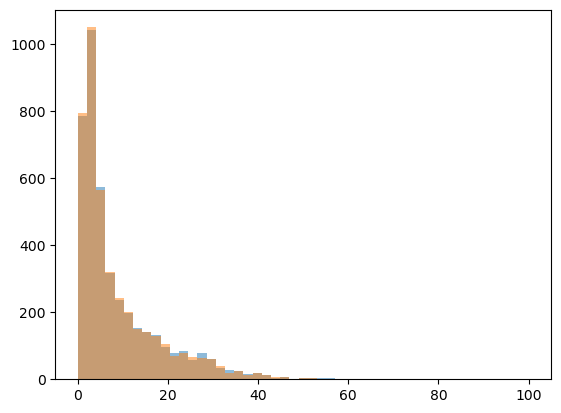

In [98]:
plt.hist(master['dR_err'] *3600 * 1000, np.linspace(0, 100), alpha = 0.5)
plt.hist(master['raErr'] * 3600 * 1000, np.linspace(0, 100), alpha = 0.5)

In [48]:
print(master['raErr', 'decErr', 'ra_dec_Cov', 'dR_err'][0:10])

   raErr       decErr    ra_dec_Cov         dR_err        
    deg         deg         deg2                          
----------- ----------- ----------- ----------------------
1.43614e-06  1.6308e-06 -8.3025e-15 1.4448782511456578e-06
3.23356e-07 3.65949e-07 6.98319e-17 3.2620607675072314e-07
4.69338e-07 5.30423e-07 3.72264e-16 4.7351886815072103e-07
1.33253e-06 1.42338e-06 6.52806e-14  1.349893780256157e-06
         --          --          --                    nan
1.43114e-06 1.54843e-06 6.05315e-14 1.4474372579213322e-06
3.63583e-07  3.8632e-07 5.28904e-15  3.681951678685995e-07
  7.399e-07  7.7307e-07 2.69474e-14  7.500221483908144e-07
3.62032e-07 3.93177e-07 3.56302e-15  3.660912846051437e-07
3.31496e-07 3.49219e-07 4.92448e-15 3.3584715857949197e-07


In [65]:
visit_table[0:10]

airmass,altitude,azimuth,band_visit,dec_visit,expTime,ra_visit,skyRotation,visit,zenithDistance,expMidptMJD
,deg,deg,,deg,s,deg,deg,,deg,d
float64,float64,float64,object,float64,float64,float64,float64,int64,float64,float64
1.11495130884417,63.728833123379005,266.980929480211,i,-28.2421867522035,30.0,53.2580044286368,102.799155952827,2024110800284,26.271166876620995,60623.29352718179
1.30619723884453,49.913376932416,98.7430041008398,i,-28.0968275668875,30.0,53.2354699531342,255.14141952641796,2024111100078,40.086623067584,60626.07392975119
1.25319132389766,52.8954636735348,97.6951028416505,r,-28.1997359016869,30.0,53.2806540886445,255.141473747963,2024111100083,37.1045363264652,60626.08363798041
1.24925785844233,53.1351689150959,97.5969720357484,i,-28.1998677821609,30.0,53.2805446601658,255.141459531569,2024111100084,36.8648310849041,60626.08441337969
1.24670277425169,53.2924603492012,97.334777453932,i,-28.0851028387333,30.0,53.2808136692959,255.141508180416,2024111100085,36.7075396507988,60626.08501231477
1.24280310999663,53.5348475469058,97.2329507565505,r,-28.084555767346,30.0,53.280619514542,255.14141635152197,2024111100086,36.4651524530942,60626.08579775464
1.21507228650616,55.3485370171637,96.7300975853252,i,-28.2277958328497,30.0,52.9583126458003,255.14133426530398,2024111100093,34.6514629828363,60626.09065574071
1.21158190919538,55.5889730839232,96.6293772220931,r,-28.2276414461571,30.0,52.9575249519527,255.141593141323,2024111100094,34.4110269160768,60626.091431545254
